# GLU vs. GRSU vs. ALMM

In [53]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA

# Import functions from Chen et. al.
from graph_active_learning_functions import *

## Synthetic Linear Data

In [54]:
# Generate Random data
samples = 2000 # N
channels = 300 # p
np.random.seed(42)

# Create random labels and abundance matrix
L = np.random.uniform(0,1,samples)
A = np.array([L,1-L])

# Smooth out the two spectras
s_1 = gaussian_filter(np.random.uniform(0,1,channels),2)
s_2 = gaussian_filter(np.random.uniform(0,1,channels),2)

S_T = np.array([s_1,s_2])

S = S_T.T


# Create the linear mixing model
X=S@A
error_std = 0.05

E = np.random.normal(loc=0.0, scale=error_std, size=X.shape)

X=X+E

In [55]:
# GLU

# Pick best parameters
# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# best_params_GLU = parameter_testing(X, A, S, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = False)

alpha_0 = 10
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 24.440980996382507
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_GLU, S_f_GLU, A_rmse_GLU, S_sad_GLU = run_unmixing_pipeline_example(X, A, S, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 21.39481515797743
Final Endmember SAD: 3.046165838405078


In [56]:
# GRSU

# Pick best parameters
# best_params_GRSU = parameter_testing(X, A, S, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = True)

alpha_0 = 10
lam_0 = 10
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 5.589934953534332
# Best alpha: 10
# Best lambda: 10
# Best gamma: 0.01
# Best rho: 0.01

# Run on best parameters
A_f_GRSU, S_f_GRSU, A_rmse_GRSU, S_sad_GRSU = run_unmixing_pipeline_example(X, A, S, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 3.073787352255858
Final Endmember SAD: 2.516147601278474


In [57]:
# ALMM

alpha = 2e-4
beta = 2e-3
gamma = 5e-3
eta = 5e-3
maxIter = 50 # changed from 30


# Pick the best alpha
best_rmse = np.inf
best_alpha = None

alpha_vals = [2e-3, 6e-4, 2e-4, 6e-5, 2e-5]
for a in alpha_vals:

    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X, S, a, beta, gamma, eta, maxIter)

    rmse = RMSE(A_f, A)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# alpha=0.002000 -> RMSE=19.5170
# alpha=0.000600 -> RMSE=11.6159
# alpha=0.000200 -> RMSE=9.9700
# alpha=0.000060 -> RMSE=12.6079
# alpha=0.000020 -> RMSE=13.9909

# Best alpha: 0.0002, RMSE: 9.9700

E_f_ALMM, A_f_ALMM, T_f_ALMM, B_f_ALMM = algo_2_almm_optimized(X, S, best_alpha, beta, gamma, eta, maxIter)

alpha=0.002000 -> RMSE=19.5170
alpha=0.000600 -> RMSE=11.6159
alpha=0.000200 -> RMSE=9.9700
alpha=0.000060 -> RMSE=12.6079
alpha=0.000020 -> RMSE=13.9909

Best alpha: 0.0002, RMSE: 9.9700


In [58]:
# Iteration testing
for iters in [10, 15, 20, 25, 30, 40, 50]:
    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X=X, S=S, alpha=best_alpha, beta=beta, gamma=gamma, eta=eta, maxIter=iters) 
    corr = np.corrcoef(A_f[0], A[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f
    else:
        A_f_corrected = A_f

    rmse = RMSE(A_f_corrected, A)  # Calculate RMSE
    print(f"maxIters={iters} -> RMSE={rmse:.4f}")

maxIters=10 -> RMSE=13.4022
maxIters=15 -> RMSE=10.9897
maxIters=20 -> RMSE=6.9709
maxIters=25 -> RMSE=9.2020
maxIters=30 -> RMSE=10.0059
maxIters=40 -> RMSE=9.9700
maxIters=50 -> RMSE=9.9700


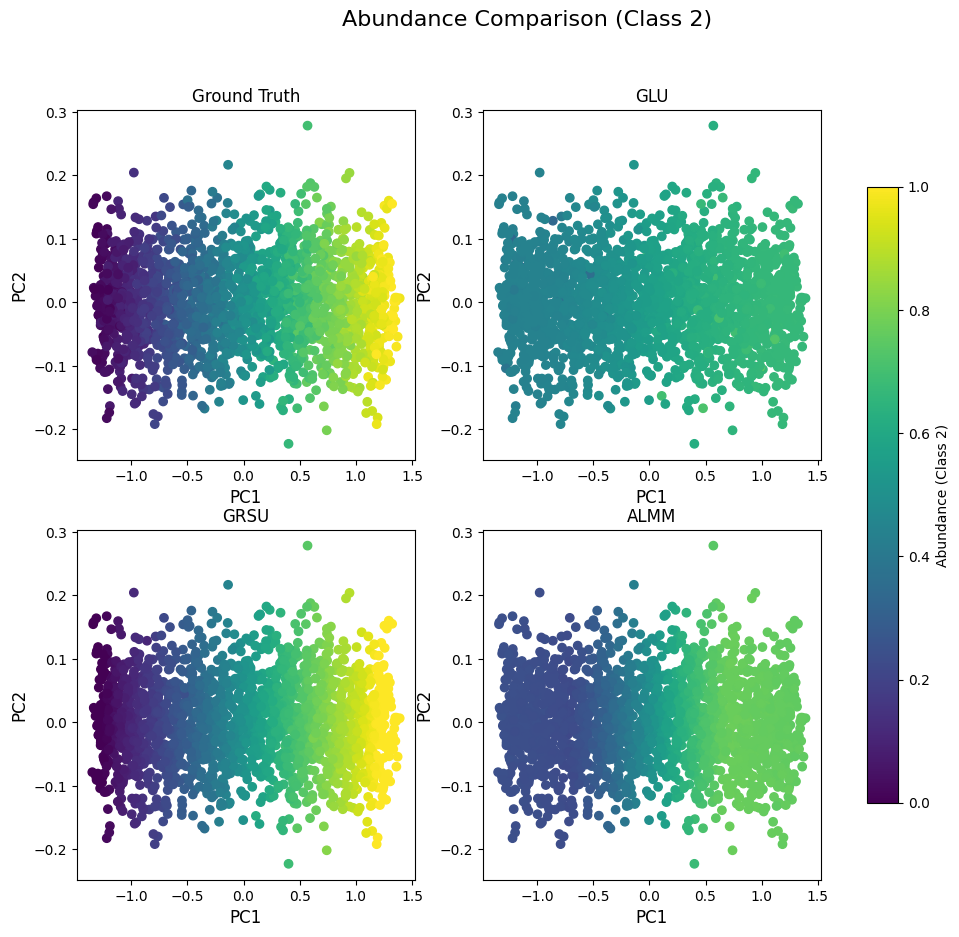

In [59]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM
sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_ALMM[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()

## Nonlinear Synthetic Data

In [60]:
data = np.load('my_custom_dataset.npy', allow_pickle=True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 250, 30)
Shape of A_gt (Abundance Map): (2, 2500)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.53910909 0.46784716 0.51651596 0.51511246 0.54243879 0.52064358
 0.51943605 0.52593777 0.53434579 0.51118315 0.51952582 0.45491021
 0.48604329 0.50390983 0.47451358 0.48900189 0.55472187 0.53542633
 0.46566486 0.46165341 0.51478674 0.51466119 0.51180038 0.5016153
 0.53460008 0.47453781 0.47549698 0.51345648 0.47629452 0.53555711]


In [61]:
# Grabbing X, S, and A from the file
A_gt_nl = data['A_gt']
S_gt_nl = data['S_gt']
X_nl = data['X']

# Checking the shapes
print(type(S_gt_nl))
print(S_gt_nl.shape)
print(S_gt_nl.dtype)

print(type(A_gt_nl))
print(A_gt_nl.shape)
print(A_gt_nl.dtype)

print("Shape of X:", X_nl.shape)

# Reshaping X from spatial image (10, 1000, 30) to 2D image (30, 10000)
H, W, p = X_nl.shape  # H=10, W=1000, p=30
X_nl_flat = X_nl.reshape(-1, p).T  # reshape to (p, N) = (30, 10000)

print(X_nl_flat.shape)  # should print (30, 10000)

<class 'numpy.ndarray'>
(30, 2)
float64
<class 'numpy.ndarray'>
(2, 2500)
float64
Shape of X: (10, 250, 30)
(30, 2500)


In [62]:
# GLU

# Pick best parameters
# samples = 2500
# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# best_params_GLU = parameter_testing(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = False)

samples = 2500
alpha_0 = 100
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 42.48586925173367
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_nl_GLU, S_f_nl_GLU, A_rmse_nl_GLU, S_sad_nl_GLU = run_unmixing_pipeline_example(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 27.072536191060763
Final Endmember SAD: 15.413333060672905


In [63]:
# GRSU

# Pick best parameters
# best_params_GRSU = parameter_testing(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = True)

alpha_0 = 10
lam_0 = 1
gamma_0 = 0.01
rho_0 = 10.0

# Best RMSE + SAD: 28.487002826613214
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 10.0

# Run on best parameters
A_f_nl_GRSU, S_f_nl_GRSU, A_rmse_nl_GRSU, S_sad_nl_GRSU = run_unmixing_pipeline_example(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 12.33336375953646
Final Endmember SAD: 16.153639067076753


In [64]:
# ALMM

alpha = 2e-3 # I think this was from a previous test
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
maxIter = 50 # changed from 30

# Pick the best alpha
best_rmse = np.inf
best_alpha = None

alpha_vals = [2e-3, 6e-4, 2e-4, 6e-5, 2e-5]

for a in alpha_vals:

    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X_nl_flat, S_gt_nl, a, beta, gamma, eta, maxIter)

    # Check for labeling issues
    corr = np.corrcoef(A_f[0], A_gt_nl[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f
    else:
        A_f_corrected = A_f

    rmse = RMSE(A_f_corrected, A_gt_nl)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# alpha=0.002000 -> RMSE=73.8551
# alpha=0.000600 -> RMSE=71.0646
# alpha=0.000200 -> RMSE=67.2571
# alpha=0.000060 -> RMSE=61.1394
# alpha=0.000020 -> RMSE=58.8132

# Best alpha: 2e-05, RMSE: 14.0524


E_f_nl_ALMM, A_f_nl_ALMM, T_f_nl_ALMM, B_f_nl_ALMM = algo_2_almm_optimized(X_nl_flat, S_gt_nl, best_alpha, beta, gamma, eta, maxIter)

alpha=0.002000 -> RMSE=32.7562
alpha=0.000600 -> RMSE=25.5850
alpha=0.000200 -> RMSE=20.4044
alpha=0.000060 -> RMSE=15.0238
alpha=0.000020 -> RMSE=14.0524

Best alpha: 2e-05, RMSE: 14.0524


In [65]:
# Iteration testing
for iters in [10, 15, 20, 25, 30, 40, 50]:
    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X=X_nl_flat, S=S_gt_nl, alpha=best_alpha, beta=beta, gamma=gamma, eta=eta, maxIter=iters) 
    corr = np.corrcoef(A_f[0], A_gt_nl[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f
    else:
        A_f_corrected = A_f

    rmse = RMSE(A_f_corrected, A_gt_nl)  # Calculate RMSE
    print(f"maxIters={iters} -> RMSE={rmse:.4f}")

maxIters=10 -> RMSE=11.7365
maxIters=15 -> RMSE=12.7489
maxIters=20 -> RMSE=13.7711
maxIters=25 -> RMSE=14.0673
maxIters=30 -> RMSE=14.0524
maxIters=40 -> RMSE=14.0524
maxIters=50 -> RMSE=14.0524


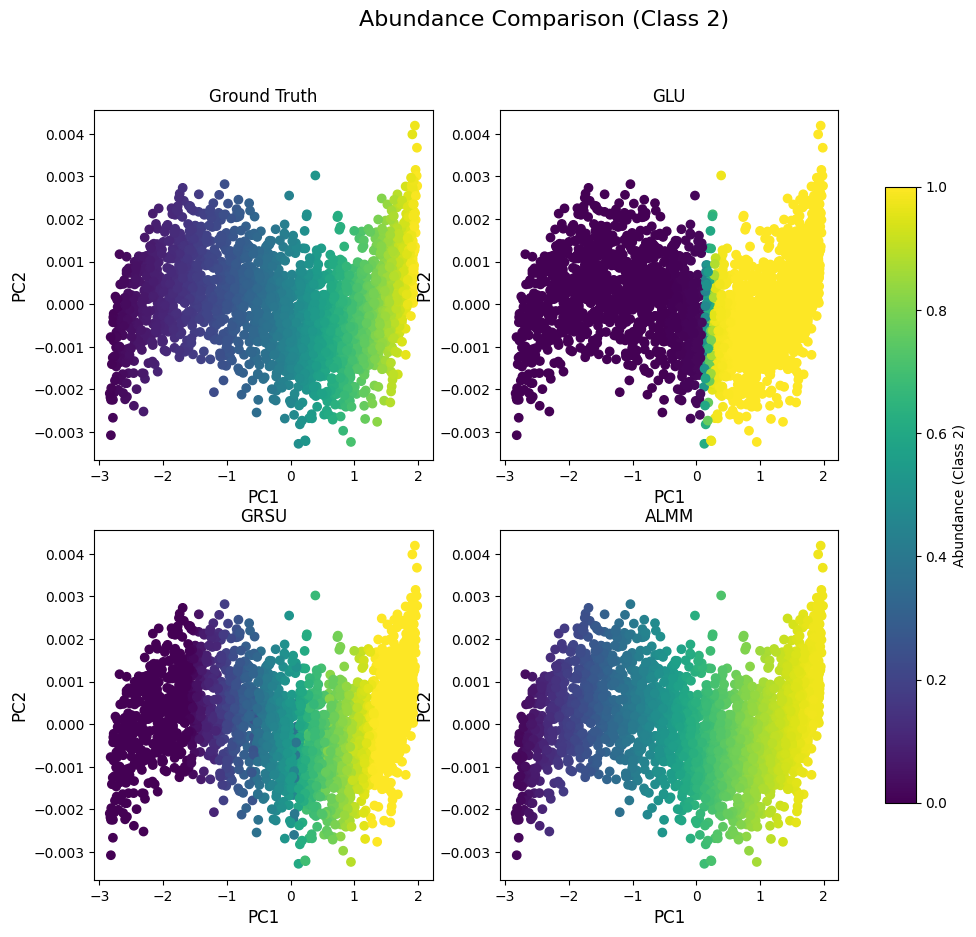

In [66]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X_nl_flat.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_gt_nl[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_nl_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_nl_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM
# print(np.corrcoef(A_f_nl_ALMM[0], A_gt_nl[0])[0,1])
# Negative correlation, so flip the abundances and recalculate RMSE
A_f_nl_ALMM_fixed = 1 - A_f_nl_ALMM

# print(RMSE(A_f_nl_ALMM_fixed, A_gt_nl))
# RMSE: 14.052370817831669

sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_nl_ALMM_fixed[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()

## Chemical Synthetic Data


In [67]:
# TODO: figure out the code from old_chem_code
data_chem = np.load('synth_chem_data.npy', allow_pickle = True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data_chem.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (Chemistry Sample):", data_chem['X'].shape)
print("Shape of A_gt (Abundance Map):", data_chem['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data_chem['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst chemical's concentration in X (how much of class 1?):\n", data_chem['X'][0, 0])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1000, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1000, 2)

First chemical's concentration in X (how much of class 1?):
 1.1670295769786863


In [68]:
# Grabbing X, S, and A from the file
A_gt_chem= data_chem['A_gt']
S_gt_chem = data_chem['S_gt']
X_chem = data_chem['X']

# Checking the shapes
print(type(S_gt_chem))
print(S_gt_chem.shape)
print(S_gt_chem.dtype)

print(type(A_gt_chem))
print(A_gt_chem.shape)
print(A_gt_chem.dtype)

print("Shape of X:", X_chem.shape)

<class 'numpy.ndarray'>
(1000, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1000, 1000)


In [69]:
# GLU

# Pick best parameters
samples = 1000
# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# best_params_GLU = parameter_testing(X_chem, A_gt_chem, S_gt_chem, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = False)

#samples = 1000
alpha_0 = 100
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Tested on p = 10000 frequencies:
# Best RMSE + SAD: 44.59750812222522
# Best alpha: 50
# Best lambda: 5
# Best gamma: 0.1
# Best rho: 100.0

# Tested on p = 1000 frequencies:
# Best RMSE + SAD: 42.508042837023396
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_chem_GLU, S_f_chem_GLU, A_rmse_chem_GLU, S_sad_chem_GLU = run_unmixing_pipeline_example(X_chem, A_gt_chem, S_gt_chem, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 13.959363249957091
Final Endmember SAD: 28.548679742458894


In [70]:
# GRSU

# Pick best parameters
# best_params_GRSU = parameter_testing(X_chem, A_gt_chem, S_gt_chem, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = True)

alpha_0 = 0.055
lam_0 = 1000
gamma_0 = 100.0
rho_0 = 100.0

# Tested on p = 10000 frequencies:
# Best RMSE + SAD: 41.14798830301321
# Best alpha: 50
# Best lambda: 5000
# Best gamma: 100.0
# Best rho: 100.0

# Tested on p = 1000 frequencies:
# Best RMSE + SAD: 30.00716397895267
# Best alpha: 0.055
# Best lambda: 1000
# Best gamma: 100.0
# Best rho: 100.0

# Run on best parameters
A_f_chem_GRSU, S_f_chem_GRSU, A_rmse_chem_GRSU, S_sad_chem_GRSU = run_unmixing_pipeline_example(X_chem, A_gt_chem, S_gt_chem, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 6.3632941228207205
Final Endmember SAD: 23.643873582363188


In [71]:
# ALMM

alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
maxIter = 20 # changed from 50

# Pick the best alpha
best_rmse = np.inf
best_alpha = 1e-6

alpha_vals = [5.5e-2, 1.5e-2, 5.5e-3, 1.5e-3, 5.5e-4]

# alpha=0.055000 -> RMSE=41.4211
# alpha=0.015000 -> RMSE=40.2388
# alpha=0.005500 -> RMSE=39.8036
# alpha=0.001500 -> RMSE=39.9866
# alpha=0.000550 -> RMSE=39.4720

# Best alpha: 0.00055 (5.5e-4), RMSE: 39.4720

alpha_vals = [3e-4, 4e-4, 5.5e-4, 7e-4, 1e-3, 1.5e-3]

# alpha=0.000300 -> RMSE=36.7682
# alpha=0.000400 -> RMSE=37.9547
# alpha=0.000550 -> RMSE=37.7692
# alpha=0.000700 -> RMSE=37.9755
# alpha=0.001000 -> RMSE=39.8564
# alpha=0.001500 -> RMSE=39.7136

# Best alpha: 0.0003, RMSE: 36.7682

alpha_vals = [3e-4, 2e-4, 1.5e-4, 1e-4, 5e-5]

# alpha=0.000300 -> RMSE=36.7682
# alpha=0.000200 -> RMSE=35.7529
# alpha=0.000150 -> RMSE=35.3302
# alpha=0.000100 -> RMSE=34.8831
# alpha=0.000050 -> RMSE=34.4270

# Best alpha: 5e-05, RMSE: 34.4270

alpha_vals = [5e-5, 2e-5, 1e-5, 5e-6, 1e-6]

# alpha=0.000050 -> RMSE=34.4270
# alpha=0.000020 -> RMSE=34.1846
# alpha=0.000010 -> RMSE=34.1110
# alpha=0.000005 -> RMSE=34.0759
# alpha=0.000001 -> RMSE=34.0488

# Best alpha: 1e-06, RMSE: 34.0488

# for a in alpha_vals:

#     E_f, A_f, T_f, B_f = algo_2_almm_optimized(X_chem, S_gt_chem, a, beta, gamma, eta, maxIter)

#     # Check for labeling issues
#     corr = np.corrcoef(A_f[0], A_gt_chem[0])[0, 1]
#     if corr < 0:
#         A_f_corrected = 1 - A_f
#     else:
#         A_f_corrected = A_f

#     rmse = RMSE(A_f_corrected, A_gt_chem)  # Calculate RMSE
#     print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

#     if rmse < best_rmse:
#         best_rmse = rmse
#         best_alpha = a

# print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")


E_f_chem_ALMM, A_f_chem_ALMM, T_f_chem_ALMM, B_f_chem_ALMM = algo_2_almm_optimized(X_chem, S_gt_chem, best_alpha, beta, gamma, eta, maxIter)

In [72]:
# Iteration testing
for iters in [10, 15, 20, 25, 30, 40, 50]:
    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X=X_chem, S=S_gt_chem, alpha=best_alpha, beta=beta, gamma=gamma, eta=eta, maxIter=iters) 
    corr = np.corrcoef(A_f[0], A_gt_chem[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f
    else:
        A_f_corrected = A_f

    rmse = RMSE(A_f_corrected, A_gt_chem)  # Calculate RMSE
    print(f"maxIters={iters} -> RMSE={rmse:.4f}")

maxIters=10 -> RMSE=33.9181
maxIters=15 -> RMSE=33.9219
maxIters=20 -> RMSE=34.0488
maxIters=25 -> RMSE=35.1357
maxIters=30 -> RMSE=38.7601
maxIters=40 -> RMSE=39.4278
maxIters=50 -> RMSE=39.4278


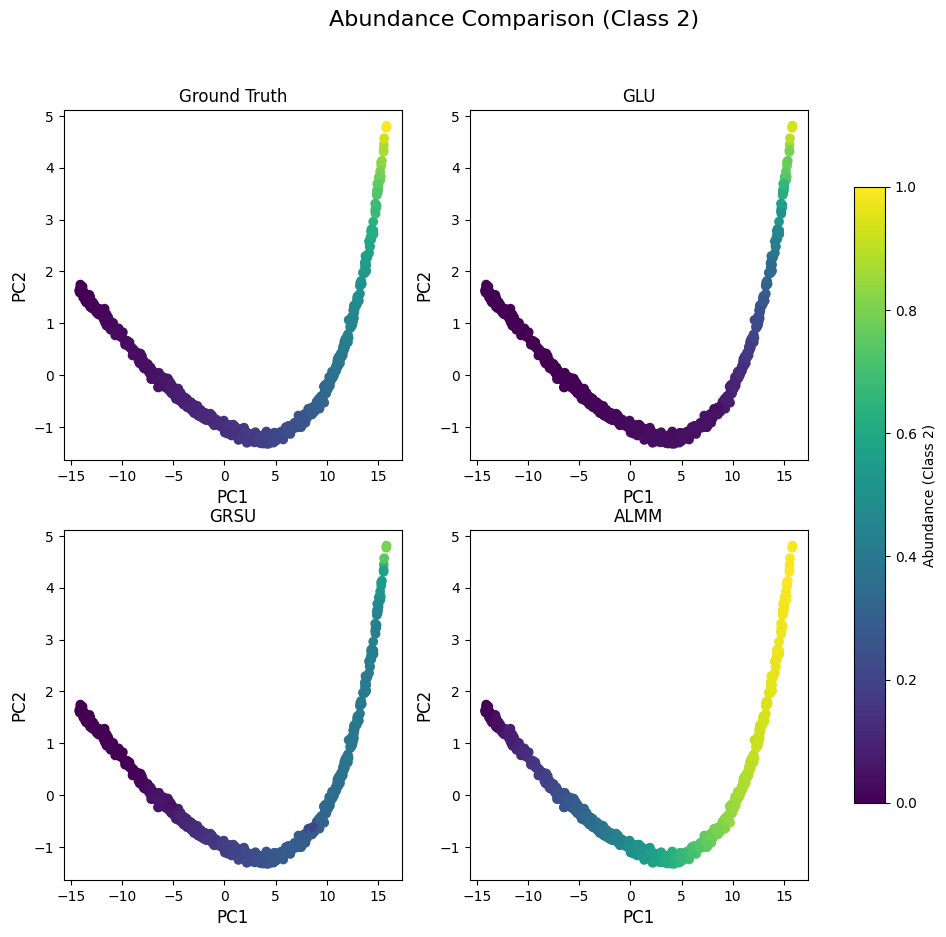

In [73]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X_chem.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_gt_chem[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_chem_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_chem_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM
sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_chem_ALMM[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()

# Urban Dataset

In [74]:
# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data/processed_data/urban/urban_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 1. Let's check X just to be sure it IS an array
print("Type of X:", type(data['X']))
if hasattr(data['X'], 'shape'):
    print("Shape of X:", data['X'].shape)

# 2. Let's peek inside the dictionary 'A'
print("\nType of A:", type(data['A']))
if isinstance(data['A'], dict):
    print("Keys inside A:", data['A'].keys())

# 3. Let's peek inside the dictionary 'S'
print("\nType of S:", type(data['S']))
if isinstance(data['S'], dict):
    print("Keys inside S:", data['S'].keys())

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])


In [75]:
A_list= data['A']
S_list = data['S']
X_urban = data['X']


S_gt_urban = S_list['S_ref']
A_gt_urban = A_list['A_ref']


print(S_gt_urban.shape)
print(A_gt_urban.shape)

(162, 4)
(4, 94249)


In [76]:
# Example: grab a 50x50 spatial patch instead of random pixels
H, W = 307, 307
patch_size = 50
row_start, col_start = 100, 100  # pick wherever

X_urban_img = X_urban.T.reshape(H, W, -1)  # reshape to (307, 307, p)
patch = X_urban_img[row_start:row_start+patch_size, col_start:col_start+patch_size, :]
X_urban_test = patch.reshape(-1, patch.shape[-1]).T  # back to (p, N_patch)

A_gt_urban_img = A_gt_urban.T.reshape(H, W, -1)
patch_gt_urban = A_gt_urban_img[row_start:row_start+patch_size, col_start:col_start+patch_size, :]
A_gt_urban_test = patch_gt_urban.reshape(-1, patch_gt_urban.shape[-1]).T

In [77]:
# GLU

# Pick best parameters
# samples = 2500
# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# best_params_GLU = parameter_testing(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 4,
#                                 print_bool = False, GRSU_bool = False)

samples = 2500
alpha_0 = 20
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 20.604754586570657
# Best alpha: 20
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_urban_GLU, S_f_urban_GLU, A_rmse_urban_GLU, S_sad_urban_GLU = run_unmixing_pipeline_example(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 4,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 16.515091863060118
Final Endmember SAD: 4.08966272351054


In [78]:
# GRSU

# Pick best parameters
# best_params_GRSU = parameter_testing(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 4,
#                                 print_bool = False, GRSU_bool = True)

alpha_0 = 20
lam_0 = 100
gamma_0 = 1.0
rho_0 = 0.1

# Best RMSE + SAD: 18.255213130283096
# Best alpha: 20
# Best lambda: 100
# Best gamma: 1.0
# Best rho: 0.1

# Run on best parameters
A_f_urban_GRSU, S_f_urban_GRSU, A_rmse_urban_GRSU, S_sad_urban_GRSU = run_unmixing_pipeline_example(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 4,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 14.108716436421073
Final Endmember SAD: 4.1458763479131475


In [79]:
# ALMM

# Parameters picked directly from paper
alpha = 5e-2
beta = 5e-2
gamma = 1e-2
eta = 1e-2
maxIter = 50 # changed from 30

# Pick the best alpha
best_rmse = np.inf
best_alpha = None

alpha_vals = [alpha, alpha/10, alpha/100, alpha/1000, alpha/10000]

for a in alpha_vals:

    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X_urban_test, S_gt_urban, a, beta, gamma, eta, maxIter)

    # Check for labeling issues
    corr = np.corrcoef(A_f[0], A_gt_urban_test[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f
    else:
        A_f_corrected = A_f

    rmse = RMSE(A_f, A_gt_urban_test)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# alpha=0.050000 -> RMSE=42.8404
# alpha=0.005000 -> RMSE=36.7084
# alpha=0.000500 -> RMSE=13.9443
# alpha=0.000050 -> RMSE=13.4054
# alpha=0.000005 -> RMSE=14.5393

# Best alpha: 5e-05, RMSE: 13.4054

E_f_urban_ALMM, A_f_urban_ALMM, T_f_urban_ALMM, B_f_urban_ALMM = algo_2_almm_optimized(X_urban_test, S_gt_urban, best_alpha, beta, gamma, eta, maxIter)

alpha=0.050000 -> RMSE=42.8404
alpha=0.005000 -> RMSE=36.7084
alpha=0.000500 -> RMSE=13.9443
alpha=0.000050 -> RMSE=13.4054
alpha=0.000005 -> RMSE=14.5393

Best alpha: 5e-05, RMSE: 13.4054


In [80]:
for iters in [10, 15, 20, 25, 30, 40, 50]:
    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X=X_urban_test, S=S_gt_urban, alpha=best_alpha, beta=beta, gamma=gamma, eta=eta, maxIter=iters) 
    corr = np.corrcoef(A_f[0], A_gt_urban_test[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f
    else:
        A_f_corrected = A_f

    rmse = RMSE(A_f_corrected, A_gt_urban_test)  # Calculate RMSE
    print(f"maxIters={iters} -> RMSE={rmse:.4f}")

maxIters=10 -> RMSE=8.2461
maxIters=15 -> RMSE=7.5955
maxIters=20 -> RMSE=12.5437
maxIters=25 -> RMSE=13.4420
maxIters=30 -> RMSE=13.4055
maxIters=40 -> RMSE=13.4054
maxIters=50 -> RMSE=13.4054


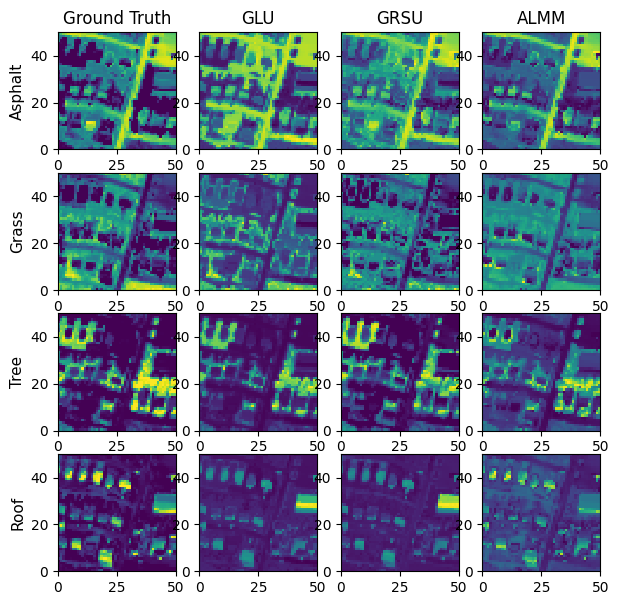

In [81]:
# Plot the images
k=4
fig, axes =  plt.subplots(nrows=k, ncols=4, figsize=(7 ,7))
A_gt_img = A_gt_urban_test.reshape(k,patch_size,patch_size)
A_f_GLU_img = A_f_urban_GLU.reshape(k,patch_size,patch_size)
A_f_GRSU_img = A_f_urban_GRSU.reshape(k,patch_size,patch_size)
A_f_ALMM_img = A_f_urban_ALMM.reshape(k,patch_size,patch_size)

class_names = ['Asphalt', 'Grass', 'Tree', 'Roof']
algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM']

# Print image of each algorithm with endmembers in this order: Asphalt, Grass, Tree, Roof
for i in range(k):
    axes[i,0].pcolormesh(A_gt_img[i], cmap='viridis')
    axes[i,1].pcolormesh(A_f_GLU_img[i], cmap='viridis')
    axes[i,2].pcolormesh(A_f_GRSU_img[i], cmap='viridis')
    axes[i,3].pcolormesh(A_f_ALMM_img[i], cmap='viridis')

    axes[i,0].set_ylabel(class_names[i], fontsize=11) # Add endmember titles

for col in range(4):
    axes[0, col].set_title(algo_names[col], fontsize=12)

# Extra testing

Trying to incorporate the graph active learning and GLU into ALMM

In [82]:
def algo_2_almm_optimized_2(X, A_0, S, alpha, beta, gamma, eta, maxIter):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    p, N = X.shape
    p, q = S.shape
    L = int(p / 2)

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_0)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    random_matrix = np.random.randn(p, L)
    E, _ = np.linalg.qr(random_matrix)

    # E = S - vca(X)
    # Ae, _, _ = vca(X, R = q)
    # E = S - Ae
    # Doesn't work since E is (p, q) here, but its supposed to be (p, L). Possible solution commented below:

    # Pad with random columns to reach L total, then orthogonalize via QR
    # np.random.seed(42)
    # pad = np.random.randn(p, L - diff.shape[1])
    # E_init_raw = np.hstack([diff, pad])   # shape (p, L)

    # E, _ = np.linalg.qr(E_init_raw)       # (p, L), orthonormal columns, but "seeded" by your real diff


    # Initialize scalars
    t = 0
    xi = 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = (xi * G) + Lambda + (xi * H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new = term1_A * diag_inv
        A_new = A_new / (A_new.sum(axis=0, keepdims=True) + 1e-10)

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E_new) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # G, H, U subproblems
        term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        term2_G = np.sign(A_new - (Lambda / xi))
        G_new = term1_G * term2_G 
        H_new = np.maximum(0, A_new - (Upsilon / xi))
        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)
    
    return E, A, T_final, B

In [83]:
def run_unmixing_pipeline_example2(X, A_gt, S_gt, N, alpha, beta, gamma, eta, maxIter, m_0 = 2, print_bool = True):

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================

    if print_bool:
        print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=int(0.004*N), num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322]
    A_hat_exact = A_gt[:, labeled_indices]
    A_hat_OH = generate_one_hot_labels(A_hat_exact)

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool:
        print("Running ALMM (and GLU) Unmixing...")

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.


    A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_OH, alpha, k=int(N*0.005))

    # The second condition number is a lot worse than the first
    # print("Condition number of S_gt_chem.T @ S_gt_chem:", np.linalg.cond(S_gt_chem.T @ S_gt_chem))
    # print("Condition number of S_GLU.T @ S_GLU:", np.linalg.cond(S_GLU.T @ S_GLU))

    E_final, A_final, T_final, B_final = algo_2_almm_optimized_2(
        X, A_GLU, S_GLU, alpha = alpha, 
        beta = beta, gamma = gamma, eta = eta, maxIter = maxIter)

    # Calculate RMSE and SAD

    # Check for labeling issues
    corr = np.corrcoef(A_final[0], A_gt[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_final
    else:
        A_f_corrected = A_final

    A_rmse = RMSE(A_f_corrected, A_gt)
    S_sad = SAD(S_GLU, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_GLU.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_GLU, A_rmse, S_sad

In [84]:
# ALMM

alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
maxIter = 20 # changed from 50
samples = 1000

# Pick the best alpha
best_rmse = np.inf
best_alpha = 1e-7

# alpha_vals = [5.5e-2, 1.5e-2, 5.5e-3, 1.5e-3, 5.5e-4]

# alpha=0.055000 -> RMSE=58.3249, SAD=31.7442
# alpha=0.015000 -> RMSE=56.6692, SAD=31.7444
# alpha=0.005500 -> RMSE=51.5308, SAD=31.7444
# alpha=0.001500 -> RMSE=15.8380, SAD=31.7444
# alpha=0.000550 -> RMSE=16.4522, SAD=31.7444

# Best alpha: 0.0015, RMSE: 15.8380, SAD: 31.744385390213132

#alpha_vals = [3e-4, 2e-4, 1e-4, 3e-5, 2e-5, 1e-5]

# alpha=0.000300 -> RMSE=14.0542, SAD=31.7444
# alpha=0.000200 -> RMSE=11.4714, SAD=31.7444
# alpha=0.000100 -> RMSE=9.7205, SAD=31.7444
# alpha=0.000030 -> RMSE=8.7814, SAD=31.7444
# alpha=0.000020 -> RMSE=8.6691, SAD=31.7444
# alpha=0.000010 -> RMSE=8.5591, SAD=31.7444

# Best alpha: 1e-05, RMSE: 8.5591, SAD: 31.74438541019126

# alpha_vals = [3e-6, 2e-6, 1e-6, 3e-7, 2e-7, 1e-7]

# alpha=0.000003 -> RMSE=8.4842, SAD=31.7444
# alpha=0.000002 -> RMSE=8.4734, SAD=31.7444
# alpha=0.000001 -> RMSE=8.4628, SAD=31.7444
# alpha=0.000000 -> RMSE=8.4554, SAD=31.7444
# alpha=0.000000 -> RMSE=8.4543, SAD=31.7444
# alpha=0.000000 -> RMSE=8.4533, SAD=31.7444

# Best alpha: 1e-07, RMSE: 8.4533, SAD: 31.7443854101981

# for a in alpha_vals:

#     A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example2(X_chem, A_gt_chem, S_gt_chem, samples, a, beta, gamma, eta, maxIter = maxIter, m_0 = 2, print_bool = False)


#     print(f"alpha={a:.6f} -> RMSE={A_rmse:.4f}, SAD={S_sad:.4f}")

#     if A_rmse < best_rmse:
#         best_rmse = A_rmse
#         best_alpha = a

# print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}, SAD: {S_sad}")

# maxIter = 20
# A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example2(X_chem, A_gt_chem, S_gt_chem, samples, best_alpha, beta, gamma, eta, maxIter = maxIter, m_0 = 2, print_bool = False)

for iters in [10, 15, 20, 25, 30, 40, 50]:
    A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example2(X_chem, A_gt_chem, S_gt_chem, samples, best_alpha, beta, gamma, eta, maxIter = iters, m_0 = 2, print_bool = False)
    # corr = np.corrcoef(A_f_chem_ALMM_GLU[0], A_gt_chem[0])[0, 1]
    # A_f_c = 1 - A_f_chem_ALMM_GLU if corr < 0 else A_f_chem_ALMM_GLU
    # rmse = RMSE(A_f_c, A_gt_chem)
    print(f"maxIter={iters} -> RMSE={A_rmse:.4f}")


maxIter=10 -> RMSE=8.9915
maxIter=15 -> RMSE=8.9804
maxIter=20 -> RMSE=8.4533
maxIter=25 -> RMSE=5.6286
maxIter=30 -> RMSE=10.6139
maxIter=40 -> RMSE=14.0183
maxIter=50 -> RMSE=14.0215


In [85]:
# For demonstration, picking the optimal amount of iterations
maxIter = 25
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example2(X_chem, A_gt_chem, S_gt_chem, samples, best_alpha, beta, gamma, eta, maxIter = maxIter, m_0 = 2, print_bool = False)
A_rmse

np.float64(5.628620342790776)

In [86]:
S_sad

np.float64(31.7443854101981)

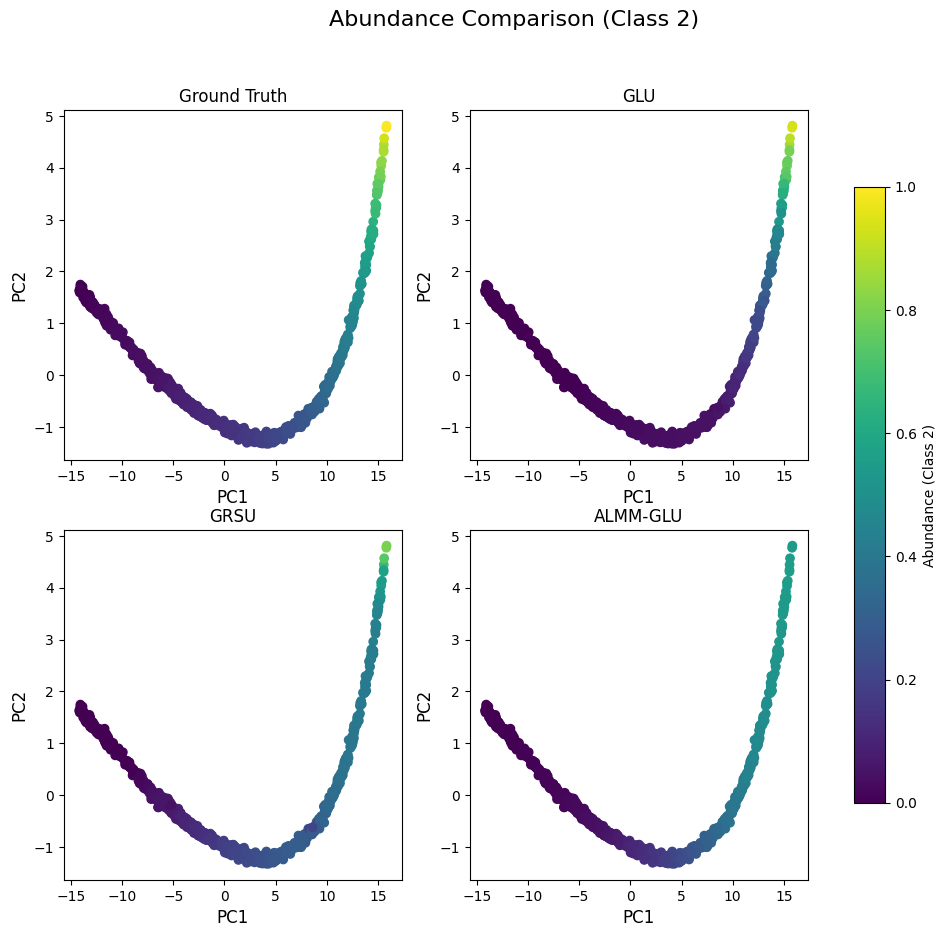

In [87]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X_chem.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_gt_chem[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_chem_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_chem_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM-GLU
sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_chem_ALMM_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM-GLU')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()